In [1]:
import sys
print(sys.executable)

d:\Documents\COLLEGE\PROJECTS\AR VR\ar_project\.venv\Scripts\python.exe


In [3]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import ar_project
print(ar_project.__file__)

None


In [1]:
from ar_project.segmentation.threshold import segment_object

print(segment_object)

<function segment_object at 0x000001AC5131ACA0>


(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

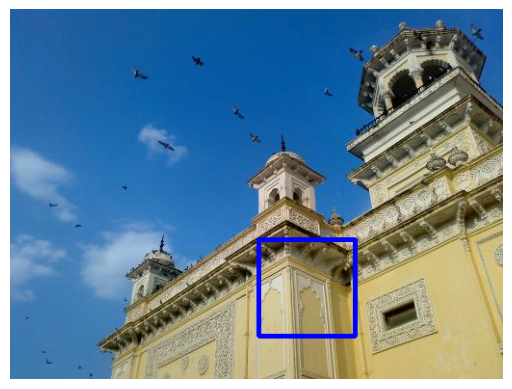

In [2]:
import cv2
import matplotlib.pyplot as plt

from ar_project.segmentation.threshold import segment_object
from ar_project.geometry.pose import find_object_center
from ar_project.rendering.overlay import overlay_cube

img = cv2.imread("../datasets/home.jpg")

mask = segment_object(img)

center = find_object_center(mask)

result = overlay_cube(img, center)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

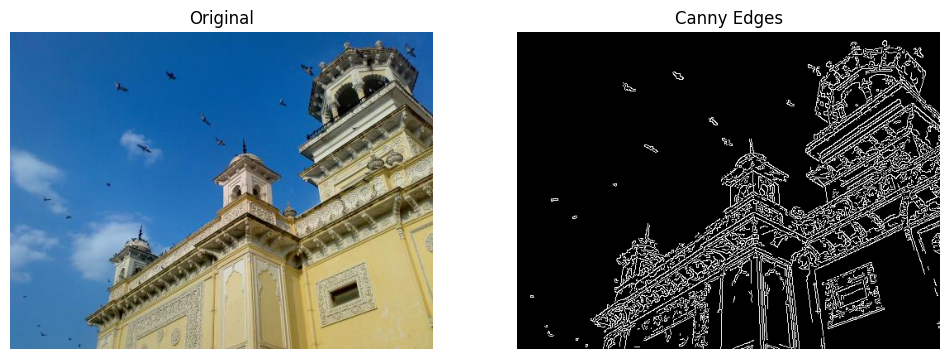

In [3]:
import cv2
import matplotlib.pyplot as plt
from ar_project.segmentation.canny import detect_edges

img = cv2.imread("../datasets/home.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Canny Edges")
plt.imshow(edges, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

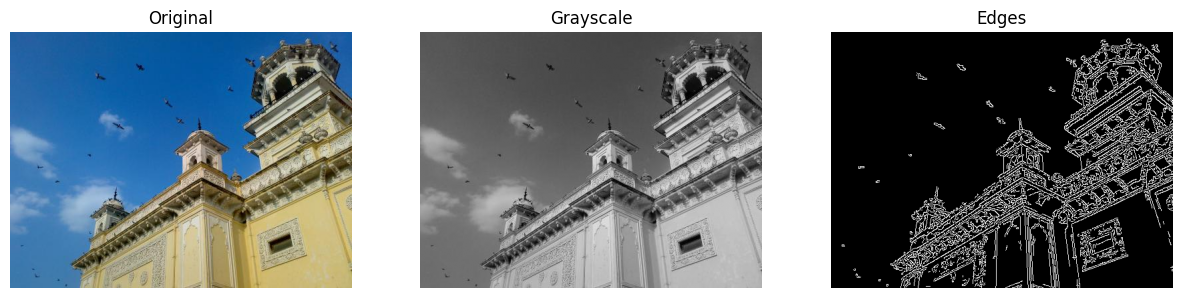

In [4]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grayscale")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Edges")
plt.imshow(edges, cmap="gray")
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

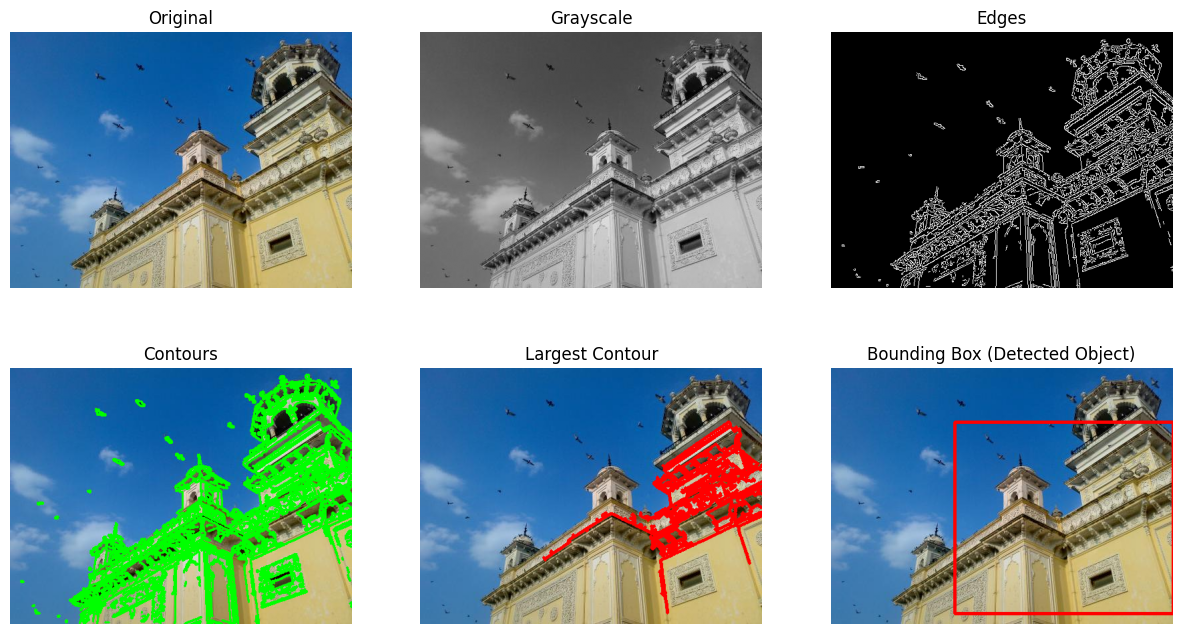

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# read image
img = cv2.imread("../datasets/home.jpg")

# convert to RGB for plotting
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detect edges
edges = cv2.Canny(gray, 100, 200)

# find contours
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# copy image for drawing
contour_img = img_rgb.copy()

# draw all contours
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

# select largest contour
largest = max(contours, key=cv2.contourArea)

# bounding box
x,y,w,h = cv2.boundingRect(largest)

bbox_img = img_rgb.copy()
cv2.rectangle(bbox_img,(x,y),(x+w,y+h),(255,0,0),3)

# plot results
plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(2,3,2)
plt.title("Grayscale")
plt.imshow(gray,cmap="gray")
plt.axis("off")

plt.subplot(2,3,3)
plt.title("Edges")
plt.imshow(edges,cmap="gray")
plt.axis("off")

plt.subplot(2,3,4)
plt.title("Contours")
plt.imshow(contour_img)
plt.axis("off")

plt.subplot(2,3,5)
plt.title("Largest Contour")
largest_img = img_rgb.copy()
cv2.drawContours(largest_img,[largest],-1,(255,0,0),3)
plt.imshow(largest_img)
plt.axis("off")

plt.subplot(2,3,6)
plt.title("Bounding Box (Detected Object)")
plt.imshow(bbox_img)
plt.axis("off")